In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
def extract_color_features(image):

    mean = cv2.mean(image)[:3]

    return np.array(mean)

In [3]:
def extract_shape_features(gray):

    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.sum(edges > 0)

    return np.array([edge_count])

In [4]:
def extract_texture_features(gray):

    radius = 1
    n_points = 8 * radius

    lbp = local_binary_pattern(
        gray,
        n_points,
        radius,
        method='uniform'
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    hist = hist.astype("float")

    hist /= (hist.sum() + 1e-6)

    return hist

In [6]:
import zipfile

with zipfile.ZipFile("/content/sample_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [28]:
dataset_path = "dataset/dataset"
image_size = 128

In [29]:
import os
for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

dataset/
    dataset/
        train/
            cat/
                cat_1.jpg
                cat_2.jpg
                cat_0.jpg
            dog/
                dog_1.jpg
                dog_2.jpg
                dog_0.jpg
        test/
            cat/
                cat_1.jpg
                cat_2.jpg
                cat_0.jpg
            dog/
                dog_1.jpg
                dog_2.jpg
                dog_0.jpg


In [35]:
features = []
labels = []

for set_name in os.listdir(dataset_path):

    set_path = os.path.join(dataset_path, set_name)

    if not os.path.isdir(set_path):
        continue

    for label in os.listdir(set_path):

        label_path = os.path.join(set_path, label)

        if not os.path.isdir(label_path):
            continue

        for file_name in os.listdir(label_path):

            image_path = os.path.join(label_path, file_name)

            image = cv2.imread(image_path)

            if image is None:
                continue

            # Resize
            image = cv2.resize(image, (image_size, image_size))

            # Normalize
            image = image / 255.0

            # Convert back for OpenCV
            image_uint8 = (image * 255).astype("uint8")

            # Grayscale
            gray = cv2.cvtColor(
                image_uint8,
                cv2.COLOR_BGR2GRAY
            )

            # Feature Extraction
            color_features = extract_color_features(image_uint8)

            shape_features = extract_shape_features(gray)

            texture_features = extract_texture_features(gray)

            # Combine Features
            combined_features = np.hstack([
                color_features,
                shape_features,
                texture_features
            ])

            features.append(combined_features)

            labels.append(label)

In [36]:
X = np.array(features)
y = np.array(labels)

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Shape: (12, 14)
Label Shape: (12,)


In [37]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
models = {

    "SVM": SVC(),

    "Random Forest": RandomForestClassifier(),

    "KNN": KNeighborsClassifier()

}

In [40]:
scores = {}

for name, model in models.items():

    print("\n===================")
    print("Training:", name)
    print("===================")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    scores[name] = acc

    print("Accuracy:", acc)

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:\n")

    print(confusion_matrix(y_test, y_pred))


Training: SVM
Accuracy: 0.3333333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3


Confusion Matrix:

[[1 0]
 [2 0]]

Training: Random Forest


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Confusion Matrix:

[[1 0]
 [0 2]]

Training: KNN
Accuracy: 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       2.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0


Confusion Matrix:

[[0 1]
 [2 0]]


In [41]:
best_model = max(scores, key=scores.get)

print("Best Model:", best_model)

print("Best Accuracy:", scores[best_model])

Best Model: Random Forest
Best Accuracy: 1.0


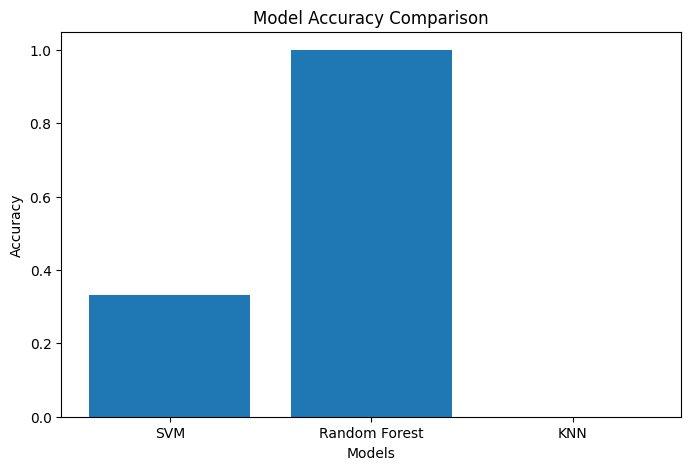

In [42]:
plt.figure(figsize=(8,5))

plt.bar(scores.keys(), scores.values())

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()